## Task 1: Credit Scoring Model

### Objective:
Build a machine learning model that predicts whether a person is creditworthy based on financial history and previous transaction data.

### Project Explanation:
Banks and financial companies use credit scoring systems to determine whether a customer is eligible for loans or credit cards. In this project, we will create a predictive model using customer financial data.

The model will analyze various financial factors such as:
* Income
* Existing debts
* Loan history
* Payment behavior
* Credit utilization
* Account balance

Based on these features, the model should classify whether a customer is:
* Low Risk
* Medium Risk
* High Risk

### Technologies & Algorithms:
We can use:
* Logistic Regression
* Decision Trees
* Random Forest
* XGBoost

### Evaluation Metrics:
* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC Score

In [1]:
import sys
!{sys.executable} -m pip install scikit-learn==1.6.1 

In [2]:
import sklearn
print(sklearn.__version__)

1.6.1


### 1. Data Loading and Initial Exploration

First, we will load the `credit_risk_dataset.csv` file into a pandas DataFrame and get a preliminary understanding of its structure and content.

In [3]:
import pandas as pd

# Load the dataset
file_path = 'models/raw/credit_risk_dataset.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
# Display basic information about the DataFrame
print('\nDataFrame Info:')
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
# Display descriptive statistics for numerical columns
print('\nDescriptive statistics for numerical columns:')
display(df.describe())


Descriptive statistics for numerical columns:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
# Check for missing values
print('\nMissing values in each column:')
display(df.isnull().sum())


Missing values in each column:


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### 2. Data Preprocessing

#### 2.1 Handling Missing Values

We observed missing values in `person_emp_length` and `loan_int_rate`. We will impute these with the median value of each column.

In [7]:
# Impute 'person_emp_length' with its median
median_emp_length = df['person_emp_length'].median()
df['person_emp_length'] = df['person_emp_length'].fillna(median_emp_length)

# Impute 'loan_int_rate' with its median
median_int_rate = df['loan_int_rate'].median()
df['loan_int_rate'] = df['loan_int_rate'].fillna(median_int_rate)

# Verify that missing values have been handled
print('Missing values after imputation:')
display(df.isnull().sum())

Missing values after imputation:


person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

#### 2.2 Outlier Treatment

Upon reviewing the descriptive statistics, `person_age` and `person_emp_length` columns show some extreme values (e.g., age 144, employment length 123). These are likely data entry errors or outliers that need to be handled to avoid distorting our model. We will cap `person_age` at a more realistic maximum (e.g., 100) and `person_emp_length` at a reasonable maximum (e.g., 60 years).

In [8]:
# Cap 'person_age' at a reasonable maximum, e.g., 100 years
df['person_age'] = df['person_age'].apply(lambda x: min(x, 100))

# Cap 'person_emp_length' at a reasonable maximum, e.g., 60 years (assuming it's in years)
df['person_emp_length'] = df['person_emp_length'].apply(lambda x: min(x, 60))

print('\nDescriptive statistics after outlier treatment for age and employment length:')
display(df[['person_age', 'person_emp_length']].describe())


Descriptive statistics after outlier treatment for age and employment length:


,person_age,person_emp_length
count,32581.000000,32581.000000
mean,27.729137,4.764126
std,6.268787,4.004465
min,20.000000,0.000000
25%,23.000000,2.000000
50%,26.000000,4.000000
75%,30.000000,7.000000
max,100.000000,60.000000


#### 2.3 Encoding Categorical Features

We need to convert categorical features (`person_home_ownership`, `loan_intent`, `loan_grade`, `cb_person_default_on_file`) into a numerical format using one-hot encoding, as machine learning models typically require numerical input.

In [9]:
# Identify categorical columns to be one-hot encoded
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True) # drop_first to avoid multicollinearity

print('Shape of DataFrame after one-hot encoding:', df_encoded.shape)
print('\nFirst 5 rows of the encoded dataset:')
display(df_encoded.head())

Shape of DataFrame after one-hot encoding: (32581, 23)

First 5 rows of the encoded dataset:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,60.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True


### 3. Feature Scaling

Feature scaling is crucial for many machine learning algorithms, especially those that rely on distance calculations (like k-NN or SVMs) or gradient descent (like Logistic Regression). We will apply StandardScaler to numerical features to normalize their range.

In [10]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling (exclude target variable 'loan_status' and already encoded columns)
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical columns
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print('First 5 rows of the dataset after feature scaling:')
display(df_encoded.head())

First 5 rows of the dataset after feature scaling:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,-0.913929,-0.114143,13.793784,4.019404,1.625921,1,3.931411,-0.691554,False,False,...,False,True,False,False,False,True,False,False,False,True
1,-1.073452,-0.911147,0.058904,-1.358650,0.042310,0,-0.657458,-0.938167,False,True,...,False,False,False,True,False,False,False,False,False,False
2,-0.435360,-0.911147,-0.939997,-0.646849,0.603713,1,3.744110,-0.691554,False,False,...,True,False,False,False,True,False,False,False,False,False
3,-0.754406,-0.009274,-0.190822,4.019404,1.369558,1,3.369508,-0.938167,False,False,...,True,False,False,False,True,False,False,False,False,False
4,-0.594883,-0.188358,0.808079,4.019404,1.058028,1,3.556809,-0.444942,False,False,...,True,False,False,False,True,False,False,False,False,True


### 4. Data Splitting

Before training any model, we need to split our dataset into training and testing sets. This ensures that we can evaluate the model's performance on unseen data, providing a more realistic assessment of its generalization ability.

In [11]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

print('\nValue counts for y_train (target distribution):')
print(y_train.value_counts(normalize=True))
print('\nValue counts for y_test (target distribution):')
print(y_test.value_counts(normalize=True))

Shape of X_train: (26064, 22)
Shape of X_test: (6517, 22)
Shape of y_train: (26064,)
Shape of y_test: (6517,)

Value counts for y_train (target distribution):
loan_status
0    0.781845
1    0.218155
Name: proportion, dtype: float64

Value counts for y_test (target distribution):
loan_status
0    0.781801
1    0.218199
Name: proportion, dtype: float64


### 5. Model Training

We will start with a Logistic Regression model as a baseline for our credit scoring prediction task. Logistic Regression is a simple yet powerful algorithm often used for binary classification.

In [12]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification

# Train the model on the training data
model.fit(X_train, y_train)

print('Logistic Regression model trained successfully.')

Logistic Regression model trained successfully.


### 6. Model Evaluation

Now, we will evaluate the performance of our trained Logistic Regression model on the test set using various metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score.

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.8679
Precision: 0.7689
Recall: 0.5640
F1-Score: 0.6507
ROC-AUC Score: 0.8693

Confusion Matrix:
[[4854  241]
 [ 620  802]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.77      0.56      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.76      0.78      6517
weighted avg       0.86      0.87      0.86      6517



### 7. Exploring Other Models: Decision Tree Classifier

Following the initial Logistic Regression model, we will now implement a Decision Tree Classifier to see if a different algorithmic approach yields better performance, especially considering the project's focus on classification techniques.

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print('Decision Tree Classifier trained successfully.')

Decision Tree Classifier trained successfully.


#### 7.1 Decision Tree Model Evaluation

Now, let's evaluate the performance of the Decision Tree Classifier using the same metrics as before.

In [15]:
# Make predictions on the test set with the Decision Tree model
dt_y_pred = dt_model.predict(X_test)
dt_y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics for Decision Tree
dt_accuracy = accuracy_score(y_test, dt_y_pred)
dt_precision = precision_score(y_test, dt_y_pred)
dt_recall = recall_score(y_test, dt_y_pred)
dt_f1 = f1_score(y_test, dt_y_pred)
dt_roc_auc = roc_auc_score(y_test, dt_y_pred_proba)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree Precision: {dt_precision:.4f}")
print(f"Decision Tree Recall: {dt_recall:.4f}")
print(f"Decision Tree F1-Score: {dt_f1:.4f}")
print(f"Decision Tree ROC-AUC Score: {dt_roc_auc:.4f}")

print('\nDecision Tree Confusion Matrix:')
print(confusion_matrix(y_test, dt_y_pred))

print('\nDecision Tree Classification Report:')
print(classification_report(y_test, dt_y_pred))

Decision Tree Accuracy: 0.8894
Decision Tree Precision: 0.7363
Decision Tree Recall: 0.7679
Decision Tree F1-Score: 0.7518
Decision Tree ROC-AUC Score: 0.8456

Decision Tree Confusion Matrix:
[[4704  391]
 [ 330 1092]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      5095
           1       0.74      0.77      0.75      1422

    accuracy                           0.89      6517
   macro avg       0.84      0.85      0.84      6517
weighted avg       0.89      0.89      0.89      6517



### 7. Exploring Other Models: Decision Tree Classifier (Redundant Section)

This section is a duplicate and has been merged with the primary Decision Tree section above.

In [16]:
# This is a redundant code cell. See the primary Decision Tree section above.

#### 7.1 Decision Tree Model Evaluation (Redundant Section)

This section is a duplicate and has been merged with the primary Decision Tree evaluation section above.

In [17]:
# This is a redundant code cell. See the primary Decision Tree evaluation section above.

In [18]:
# This is a blank cell that was removed during cleanup. It has been made a comment to avoid syntax errors.

### 8. Exploring Other Models: Random Forest Classifier

Next, we will implement a Random Forest Classifier, another powerful ensemble learning method known for its improved accuracy and ability to handle complex datasets.

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 to use all available cores

# Train the model
rf_model.fit(X_train, y_train)

print('Random Forest Classifier trained successfully.')

Random Forest Classifier trained successfully.


#### 8.1 Random Forest Model Evaluation

Let's evaluate the performance of the Random Forest Classifier.

In [20]:
# Make predictions on the test set with the Random Forest model
rf_y_pred = rf_model.predict(X_test)
rf_y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics for Random Forest
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_pred_proba)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest Recall: {rf_recall:.4f}")
print(f"Random Forest F1-Score: {rf_f1:.4f}")
print(f"Random Forest ROC-AUC Score: {rf_roc_auc:.4f}")

print('\nRandom Forest Confusion Matrix:')
print(confusion_matrix(y_test, rf_y_pred))

print('\nRandom Forest Classification Report:')
print(classification_report(y_test, rf_y_pred))

Random Forest Accuracy: 0.9317
Random Forest Precision: 0.9561
Random Forest Recall: 0.7201
Random Forest F1-Score: 0.8215
Random Forest ROC-AUC Score: 0.9313

Random Forest Confusion Matrix:
[[5048   47]
 [ 398 1024]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.96      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517



### 8. Exploring Other Models: Random Forest Classifier (Redundant Section)

This section is a duplicate and has been merged with the primary Random Forest section above.

In [21]:
# This is a redundant code cell. See the primary Random Forest section above.

#### 8.1 Random Forest Model Evaluation (Redundant Section)

This section is a duplicate and has been merged with the primary Random Forest evaluation section above.

In [22]:
# This is a redundant code cell. See the primary Random Forest evaluation section above.

### 7. Exploring Other Models: Decision Tree Classifier (Redundant Section)

This section is a duplicate and has been merged with the primary Decision Tree section above.

In [23]:
# This is a redundant code cell. See the primary Decision Tree section above.

#### 7.1 Decision Tree Model Evaluation (Redundant Section)

This section is a duplicate and has been merged with the primary Decision Tree evaluation section above.

In [24]:
# This is a redundant code cell. See the primary Decision Tree evaluation section above.

### 9. Exploring Other Models: XGBoost Classifier

Finally, we will implement the XGBoost Classifier, a highly efficient and popular gradient boosting library. XGBoost is known for its speed and performance in many machine learning tasks.

In [25]:
import xgboost as xgb

# Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train, y_train)

print('XGBoost Classifier trained successfully.')

XGBoost Classifier trained successfully.


#### 9.1 XGBoost Model Evaluation

Let's evaluate the performance of the XGBoost Classifier.

In [26]:
# Make predictions on the test set with the XGBoost model
xgb_y_pred = xgb_model.predict(X_test)
xgb_y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics for XGBoost
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall = recall_score(y_test, xgb_y_pred)
xgb_f1 = f1_score(y_test, xgb_y_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_y_pred_proba)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"XGBoost Precision: {xgb_precision:.4f}")
print(f"XGBoost Recall: {xgb_recall:.4f}")
print(f"XGBoost F1-Score: {xgb_f1:.4f}")
print(f"XGBoost ROC-AUC Score: {xgb_roc_auc:.4f}")

print('\nXGBoost Confusion Matrix:')
print(confusion_matrix(y_test, xgb_y_pred))

print('\nXGBoost Classification Report:')
print(classification_report(y_test, xgb_y_pred))

XGBoost Accuracy: 0.9345
XGBoost Precision: 0.9602
XGBoost Recall: 0.7300
XGBoost F1-Score: 0.8294
XGBoost ROC-AUC Score: 0.9517

XGBoost Confusion Matrix:
[[5052   43]
 [ 384 1038]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.96      0.73      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



### 10. Comparative Analysis and Visualization (ROC Curves)

To better understand and compare the performance of our models, we will visualize their Receiver Operating Characteristic (ROC) curves. The ROC curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) is a measure of the ability of a classifier to distinguish between classes and is used as a summary of the ROC curve.

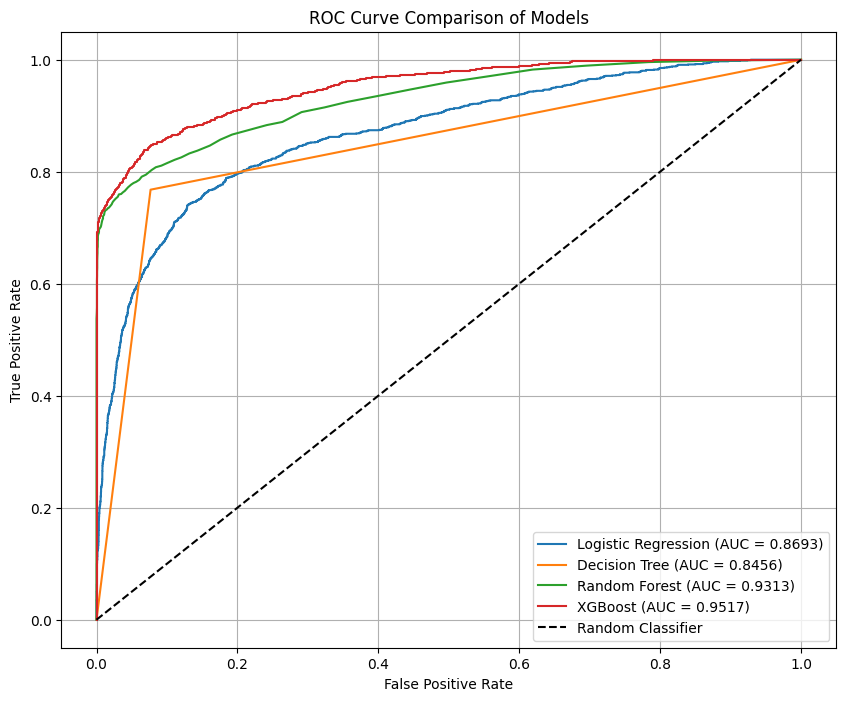

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Get ROC curve data for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_y_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_y_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_y_pred_proba)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {dt_roc_auc:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_roc_auc:.4f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [28]:
import joblib

joblib.dump(model, 'models/trained/logistic_regression_model.pkl')
print('Logistic Regression model saved.')

joblib.dump(dt_model, 'models/trained/decision_tree_model.pkl')
print('Decision Tree model saved.')

joblib.dump(rf_model, 'models/trained/random_forest_model.pkl')
print('Random Forest model saved.')

joblib.dump(xgb_model, 'models/trained/xgboost_model.pkl')
print('XGBoost model saved.')

joblib.dump(scaler, 'models/trained/scaler.pkl')
print('Scaler saved.')

Logistic Regression model saved.
Decision Tree model saved.
Random Forest model saved.
XGBoost model saved.
Scaler saved.
